In [108]:
import dill
import numpy as np
import gtsam
from gtsam import Pose3, Rot3, Point3
import matplotlib.pyplot as plt
import ipywidgets as widgets


In [109]:
with open("/home/hans-peter/ros2_ws/src/ais_robot_localization/py_tools/TrajectoryTools/ExampleTrajectories/gnss.dill", "rb") as f:
    traj_gnss = dill.load(f)

with open("/home/hans-peter/ros2_ws/src/ais_robot_localization/py_tools/TrajectoryTools/ExampleTrajectories/odom.dill", "rb") as f:
    traj_odom = dill.load(f)

with open("/home/hans-peter/ros2_ws/src/ais_robot_localization/py_tools/TrajectoryTools/ExampleTrajectories/gt.dill", "rb") as f:
    traj_gt = dill.load(f)

# assume same timestamps for simplicity
timestamps = list(traj_gnss.timestamps)

def se3_to_pose3(T):
    T = np.asarray(T)
    return Pose3(Rot3(T[:3, :3]), Point3(*T[:3, 3]))

def pose_translation(pose):
    if isinstance(pose, Pose3):
        return np.asarray(pose.translation())[0:3]
    pose = np.asarray(pose)
    return pose[:3, 3]

traj_gnss_pose3 = [se3_to_pose3(T) for T in traj_gnss.poses_se3]
traj_odom_pose3 = [se3_to_pose3(T) for T in traj_odom.poses_se3]
traj_gt_pose3 = [se3_to_pose3(T) for T in traj_gt.poses_se3]


In [117]:
sample_threshold = 1.0  # meters
sample_indices = [0]
sampled_timestamps = [timestamps[0]]
last_sample_idx = 0

for idx in range(1, len(timestamps)):
    delta = np.linalg.norm(
        pose_translation(traj_odom_pose3[idx]) - pose_translation(traj_odom_pose3[last_sample_idx])
    )
    if delta >= sample_threshold:
        sample_indices.append(idx)
        sampled_timestamps.append(timestamps[idx])
        last_sample_idx = idx

print(f"Sampling {len(sample_indices)} poses (threshold {sample_threshold} m)")


Sampling 936 poses (threshold 1.0 m)


In [118]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

# Noise models
gnss_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([1.0, 1.0, 2.0, 0.5, 0.5, 1.0])  # xyz, rpy
)

drift_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([0.005, 0.005, 0.005, 0.001, 0.001, 0.001])
)


In [119]:
T0 = Pose3()  # identity
initial.insert(0, T0)
graph.add(gtsam.PriorFactorPose3(0, T0,
    gtsam.noiseModel.Isotropic.Sigma(6, 1e-3)))


In [120]:
traj_est_sparse = []
map_odom_history = []

for node_idx, traj_idx in enumerate(sample_indices):
    if node_idx > 0:
        if not initial.exists(node_idx):
            initial.insert(node_idx, initial.atPose3(node_idx - 1))
        graph.add(
            gtsam.BetweenFactorPose3(
                node_idx - 1, node_idx, Pose3(), drift_noise
            )
        )

    odom_pose = traj_odom_pose3[traj_idx]
    gnss_pose = traj_gnss_pose3[traj_idx]

    # GNSS factor: T_map_odom ⊕ T_odom_base ≈ T_map_base^gnss
    meas = gnss_pose.compose(odom_pose.inverse())
    graph.add(gtsam.PriorFactorPose3(node_idx, meas, gnss_noise))

    optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
    result = optimizer.optimize()

    T_map_odom = result.atPose3(node_idx)
    map_odom_history.append(T_map_odom)
    traj_est_sparse.append(T_map_odom.compose(odom_pose))

    # warm start next iteration with current solution
    initial = gtsam.Values(result)

    print(f"Optimized up to node {node_idx}, traj index {traj_idx} from {len(timestamps)}  timestamps  ")


Optimized up to node 0, traj index 0 from 3549  timestamps  
Optimized up to node 1, traj index 19 from 3549  timestamps  
Optimized up to node 2, traj index 28 from 3549  timestamps  
Optimized up to node 3, traj index 35 from 3549  timestamps  
Optimized up to node 4, traj index 41 from 3549  timestamps  
Optimized up to node 5, traj index 46 from 3549  timestamps  
Optimized up to node 6, traj index 51 from 3549  timestamps  
Optimized up to node 7, traj index 56 from 3549  timestamps  
Optimized up to node 8, traj index 60 from 3549  timestamps  
Optimized up to node 9, traj index 64 from 3549  timestamps  
Optimized up to node 10, traj index 68 from 3549  timestamps  
Optimized up to node 11, traj index 72 from 3549  timestamps  
Optimized up to node 12, traj index 76 from 3549  timestamps  
Optimized up to node 13, traj index 80 from 3549  timestamps  
Optimized up to node 14, traj index 84 from 3549  timestamps  
Optimized up to node 15, traj index 87 from 3549  timestamps  
Opt

In [121]:
traj_est = []
sample_idx = 0

for t, odom_pose in zip(timestamps, traj_odom_pose3):
    while (sample_idx + 1 < len(sampled_timestamps) and
           abs(sampled_timestamps[sample_idx + 1] - t) < abs(sampled_timestamps[sample_idx] - t)):
        sample_idx += 1
    traj_est.append(map_odom_history[sample_idx].compose(odom_pose))


In [122]:
gt = np.array([p.translation() for p in traj_gt_pose3])
gnss = np.array([p.translation() for p in traj_gnss_pose3])
est = np.array([p.translation() for p in traj_est])
odom = np.array([p.translation() for p in traj_odom_pose3])


interactive(children=(IntSlider(value=3549, description='Samples', max=3549, min=2), Output()), _dom_classes=(…

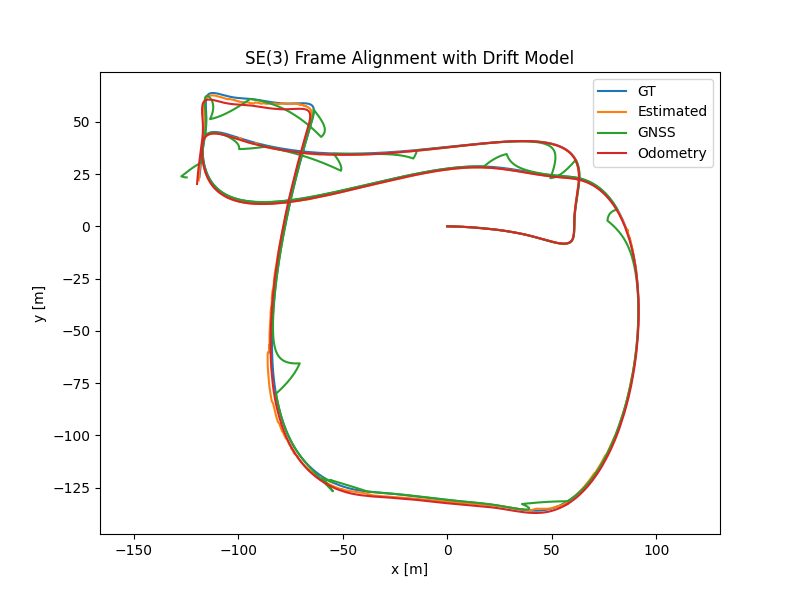

In [123]:
%matplotlib widget
fig, ax = plt.subplots(figsize=(8, 6))
slider = widgets.IntSlider(value=len(gt), min=2, max=len(gt), step=1, description="Samples")

def update_plot(idx):
    ax.clear()
    ax.plot(gt[:idx,0], gt[:idx,1], label="GT")
    ax.plot(est[:idx,0], est[:idx,1], label="Estimated")
    ax.plot(gnss[:idx,0], gnss[:idx,1], label="GNSS")
    ax.plot(odom[:idx,0], odom[:idx,1], label="Odometry")
    ax.axis("equal")
    ax.legend()
    ax.set_title("SE(3) Frame Alignment with Drift Model")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    fig.canvas.draw_idle()

widgets.interact(update_plot, idx=slider)
update_plot(slider.value)
